# **Analysis of COVID-19 Cases in Malaysia from 2020 to 2025**

# 1. Introduction

The Coronavirus Disease 2019 (COVID-19) pandemic has become one of the most significant global health crises in modern history, affecting millions of people worldwide and generating an enormous volume of health-related data. Since its emergence in late 2019, governments, healthcare organizations, and researchers have continuously collected data on confirmed cases, deaths, recoveries, vaccinations, and demographic characteristics to monitor the spread of the virus and support decision-making processes. The large scale, velocity, and variety of COVID-19 data have made traditional data processing approaches increasingly inadequate, creating a need for big data technologies capable of handling massive datasets efficiently.

Apache Spark and Apache Hive are widely adopted big data frameworks that provide scalable solutions for storing, processing, and analyzing large datasets. Apache Spark offers distributed in-memory computing capabilities that enable faster data processing and advanced analytics, while Apache Hive provides a data warehousing environment that allows users to perform SQL-like queries on large datasets stored in the Hadoop ecosystem. The integration of Spark and Hive facilitates efficient management, transformation, and analysis of COVID-19 data, enabling researchers and policymakers to extract valuable insights regarding infection trends, mortality rates, vaccination progress, and geographical distribution of cases.

This study focuses on the analysis of COVID-19 data using Apache Spark and Apache Hive to demonstrate the effectiveness of big data technologies in processing large-scale healthcare datasets.


# 2. Objectives

1. To manage and integrate COVID-19 datasets using Apache Hive and Apache Spark for efficient big data processing.

2. To perform data cleaning and preprocessing on COVID-19 datasets to ensure data quality, consistency and reliability.

3. To analyse the distribution and trends of COVID-19 cases across different states in Malaysia.

4. To investigate COVID-19 infection patterns among different age groups across Malaysian states.

5. To generate visualizations and derive insights that can support data-driven decision making in public health and healthcare management.


#3. Research Questions
This project aims to answer the following research questions:

1. Which states recorded the highest and lowest numbers of COVID-19 cases during the study period?

2. How do COVID-19 case trends vary across different states in Malaysia?

3. Which age groups were most affected by COVID-19 in different states?

4. Are there significant differences in infection patterns among age groups and states?

5. What insights can be derived from the analysis to support future public health planning and disease management strategies?


# 4. Source of data

The datasets used in this project were obtained from the Malaysian Government Open Data Portal (data.gov.my), which provides publicly accessible datasets for research and analytical purposes.

### Dataset 1: Daily COVID-19 Cases by Vaccination Status and State

**Description:**  
Contains daily COVID-19 case counts categorized by vaccination status and state in Malaysia. The dataset enables analysis of infection trends among vaccinated, partially vaccinated, and unvaccinated populations.

---

### Dataset 2: Daily COVID-19 Cases by State

**Description:**  
Provides daily reported COVID-19 cases for each state in Malaysia. This dataset is used to examine geographical trends and compare infection rates across states.


---

### Dataset 3: Daily COVID-19 Cases by Age Group and State

**Description:**  
Contains daily COVID-19 case counts categorized by age group and state. The dataset supports demographic analysis of infection patterns among different age categories.




#5. Methodology
###5.1 Environment Setup

The project was conducted within a Hadoop ecosystem managed through Apache Ambari. PuTTY was used to establish a secure remote connection to the Hadoop cluster. Apache Hive was utilized for data warehousing and SQL-based querying, while Apache Spark was employed for distributed data processing and analytical computations.

Tools Used:

1. Apache Ambari
2. PuTTY
3. Hadoop Distributed File System (HDFS)
4. Apache Hive
5. Apache Spark
6. Python

###5.2 Data Collection

Three COVID-19 datasets were obtained from the Malaysian Government Open Data Portal (data.gov.my):

Dataset 1: **Daily COVID-19 Cases by Vaccination Status and State**

Dataset 2: **Daily COVID-19 Cases by State**

Dataset 3: **Daily COVID-19 Cases by Age Group and State**

The datasets were downloaded in CSV format and transferred to the Hadoop environment for processing.

###5.3 Data Upload to HDFS
The raw datasets were uploaded into the Hadoop Distributed File System (HDFS) to facilitate distributed storage and processing.
```
hdfs dfs -mkdir /covid19
hdfs dfs -put cases.csv /covid19
hdfs dfs -put vaxstatus.csv /covid19
hdfs dfs -put age.csv /covid19
```
The uploaded files were verified using:
```
hdfs dfs -ls /covid19
```

###5.4 Hive Table Creation

### Open Hive
```
hive
```
### Create Database inside Hive Shell
```
CREATE DATABASE covid_analysis;
USE covid_analysis;
```
###Create Tables
1. Cases table
```
CREATE EXTERNAL TABLE cases (
report_date STRING,
state STRING,
cases_new INT,
cases_import INT,
cases_recovered INT,
cases_active INT,
cases_cluster INT
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
STORED AS TEXTFILE
LOCATION '/covid/cases/';
```
2. Vaccination table


```
CREATE EXTERNAL TABLE vax (
report_date STRING,
state STRING,
cases_unvax INT,
cases_pvax INT,
cases_fvax INT,
cases_boost INT
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
STORED AS TEXTFILE
LOCATION '/covid/vaxstatus/';
```
3. Age table
```
CREATE EXTERNAL TABLE age (
report_date STRING,
state STRING,
cases_child INT,
cases_adolescent INT,
cases_adult INT,
cases_elderly INT,
cases_0_4 INT,
cases_5_11 INT,
cases_12_17 INT,
cases_18_29 INT,
cases_30_39 INT,
cases_40_49 INT,
cases_50_59 INT,
cases_60_69 INT,
cases_70_79 INT,
cases_80 INT
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
STORED AS TEXTFILE
LOCATION '/covid/age/';
```







##5.5 Run Hive Analysis

**State-wise cases**
```
SELECT state, SUM(CAST(cases_new AS INT)) AS total_cases
FROM cases
GROUP BY state
ORDER BY total_cases DESC;
```
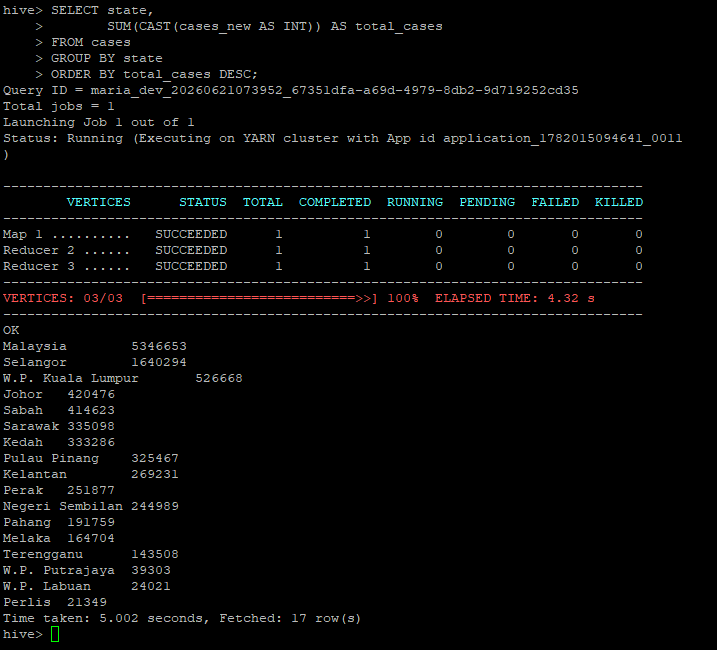

**Daily trend**
```
SELECT report_date, SUM(cases_new)
FROM cases
GROUP BY report_date
ORDER BY report_date;
```
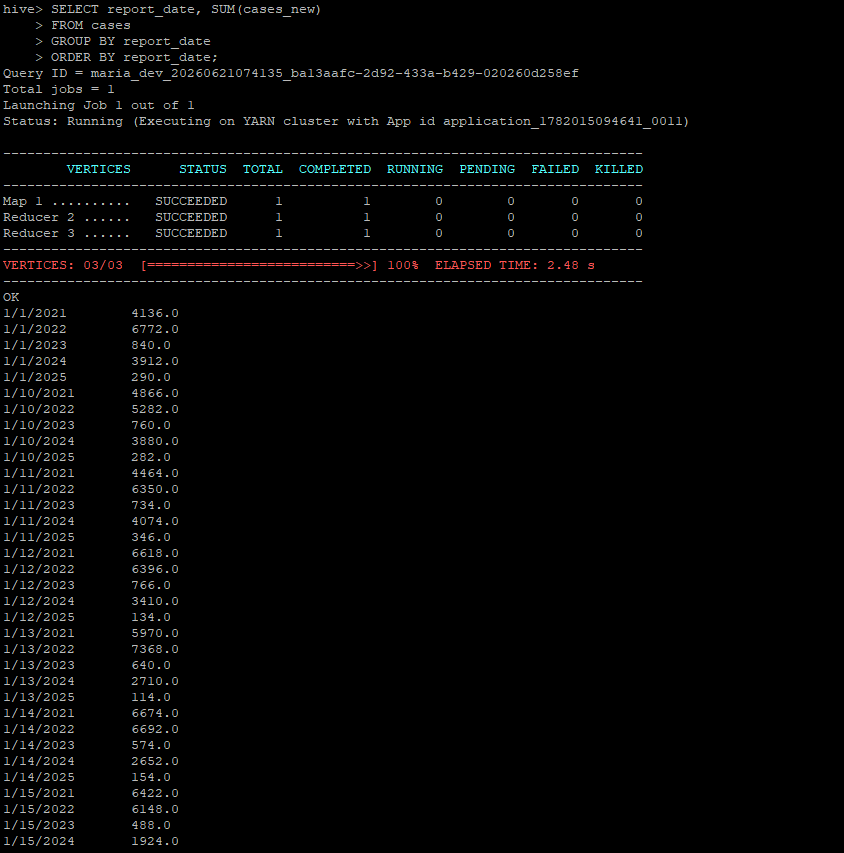

**Vaccination summary**
```
SELECT state,
SUM(cases_unvax),
SUM(cases_fvax),
SUM(cases_boost)
FROM vax
GROUP BY state;
```
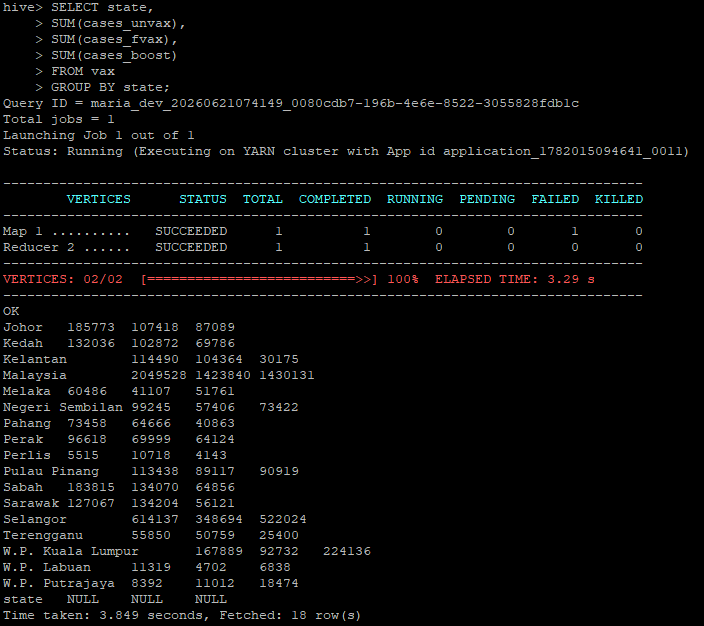

**Age group summary**
```
SELECT state,
SUM(cases_child),
SUM(cases_adult),
SUM(cases_elderly)
FROM age
GROUP BY state;
```
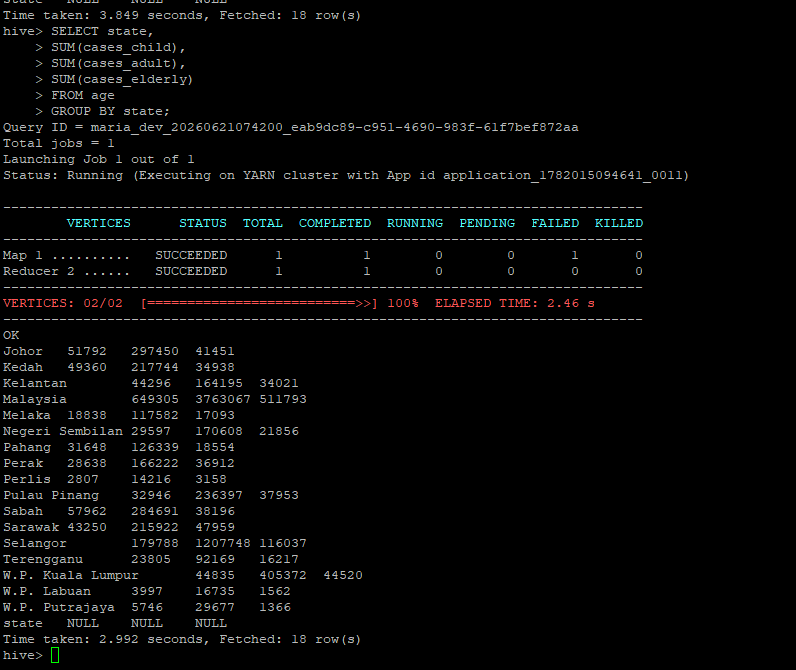
## Exit Hive


##5.6 Create Spark Script

```
vi covid_analysis1.py
```
Full script in GitHub.

##5.7 Run Spark Script


```
spark-submit covid_analysis1.py
```




# 6.0 Results and Analysis

In [21]:
from google.colab import userdata
userdata.get('covid')

'1234'

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [23]:
cases = pd.read_csv("covid_cases.csv")
age = pd.read_csv("covid_cases_age.csv")
vax = pd.read_csv("covid_cases_vaxstatus.csv")

In [24]:
cases = cases.fillna(0)
age = age.fillna(0)
vax = vax.fillna(0)

In [25]:
# REMOVE MALAYSIA ROWS

cases = cases[cases["state"] != "Malaysia"]
age = age[age["state"] != "Malaysia"]
vax = vax[vax["state"] != "Malaysia"]

The row where state "Malaysia" was excluded from the analysis because it represents a pre-calculated national aggregate of all states. Retaining this row alongside individual state records would lead to double counting during aggregation and distort analytical results.

In [26]:
cases["date"] = pd.to_datetime(cases["date"])

##6.1 Total COVID-19 Cases by State

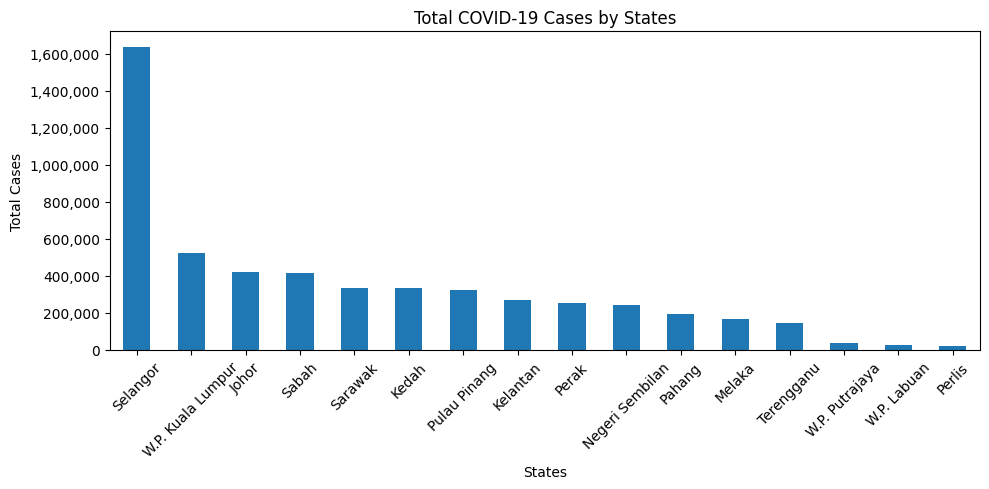

In [27]:
import matplotlib.ticker as mticker

# Calculate total cases per state
state_cases = cases.groupby("state")["cases_new"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
state_cases.plot(kind="bar")

plt.title("Total COVID-19 Cases by States")
plt.ylabel("Total Cases")
plt.xlabel("States")
plt.xticks(rotation=45)

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

The bar chart illustrates the total number of COVID-19 cases recorded across Malaysian states during the study period. Selangor reported the highest cumulative number of cases, exceeding 1.6 million, significantly surpassing all other states. This was followed by W.P. Kuala Lumpur, which recorded more than 500,000 cases, while Johor and Sabah each reported over 400,000 cases. Sarawak, Kedah, and Pulau Pinang also experienced relatively high case counts, ranging from approximately 300,000 to 350,000 cases. In contrast, states such as Kelantan, Perak, and Negeri Sembilan recorded moderate numbers of infections, while Pahang, Melaka, and Terengganu reported fewer than 200,000 cases. The lowest numbers of COVID-19 cases were observed in W.P. Putrajaya, W.P. Labuan, and Perlis, each recording fewer than 50,000 cases throughout the study period.

The results indicate a substantial variation in COVID-19 incidence across Malaysia. Highly urbanized and densely populated regions, particularly Selangor and W.P. Kuala Lumpur, experienced a much greater disease burden compared to less populated states. Factors such as higher population density, greater mobility, increased economic activity, and more frequent social interactions likely contributed to the higher transmission rates in these areas. Conversely, smaller states and federal territories recorded fewer cases, reflecting their lower population sizes and reduced levels of population concentration. Overall, the findings suggest that population density and urbanization played important roles in influencing the spread of COVID-19 in Malaysia, with Selangor emerging as the most affected state during the pandemic period.


##6.2 Daily Trend Lines for 5 Case Types

| Variable         | Type        | Description |
|-----------------|------------|-------------|
| `report_date`          | Date       | Date in YYYY-MM-DD format. Represents the report date. |
| `state`         | Categorical | One of 16 states in Malaysia, or "Malaysia" (national level). |
| `cases_new`     | Integer    | Number of new COVID-19 cases reported in the 24 hours since the last report. Based on report date, not test date. |
| `cases_import`  | Integer    | Number of cases imported from abroad (infected outside the country). |
| `cases_recovered` | Integer  | Number of recoveries reported in the last 24 hours. |
| `cases_active`  | Integer    | Number of active cases who have not recovered or died. |
| `cases_cluster` | Integer    | Number of cases linked to clusters. Sporadic cases = `cases_new - cases_cluster`. |

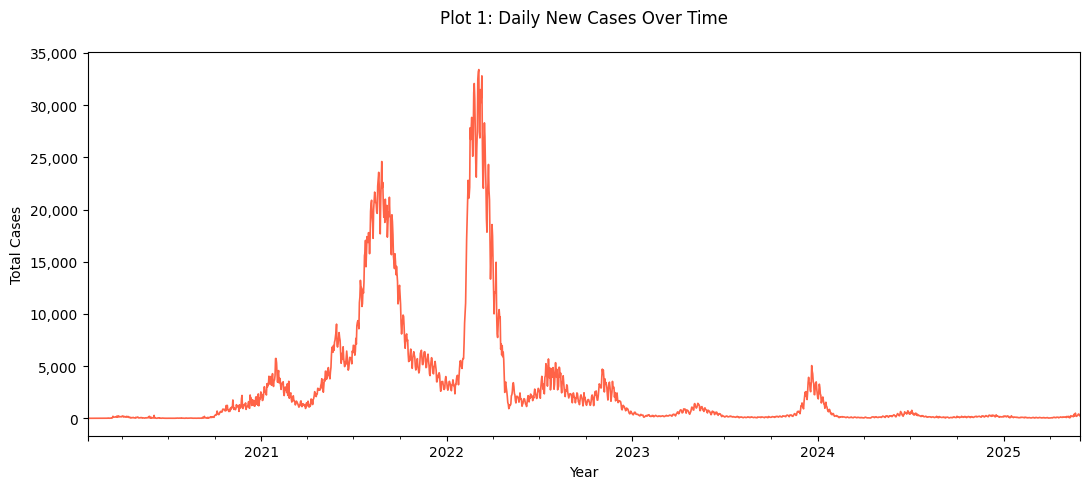

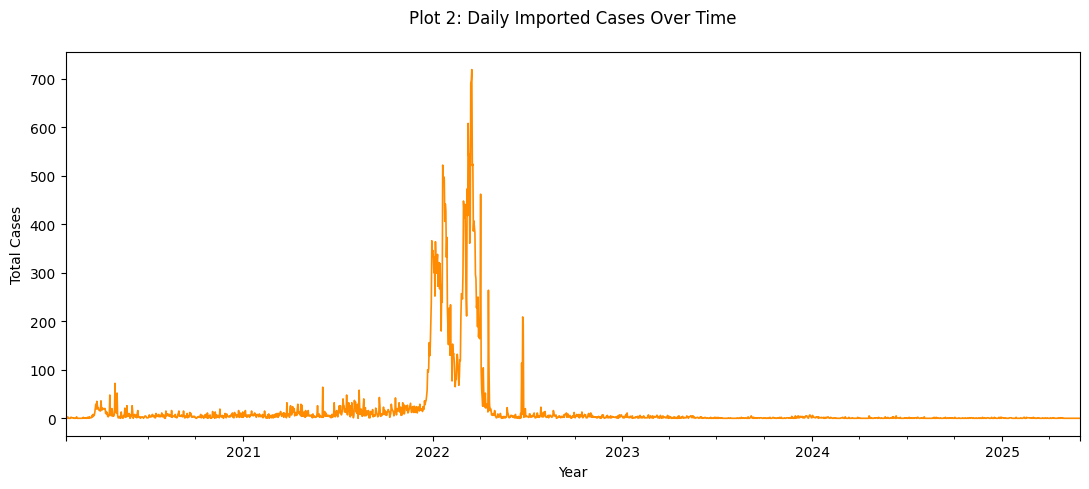

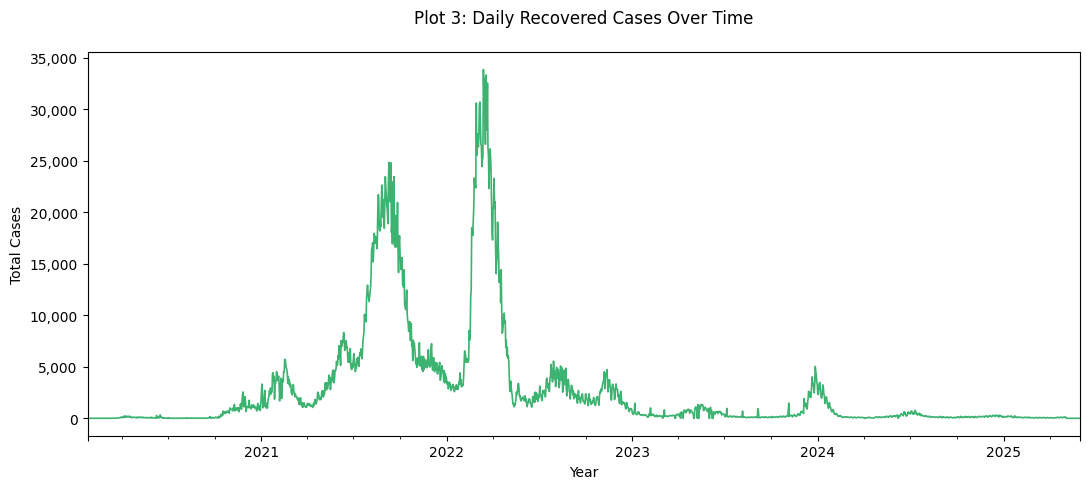

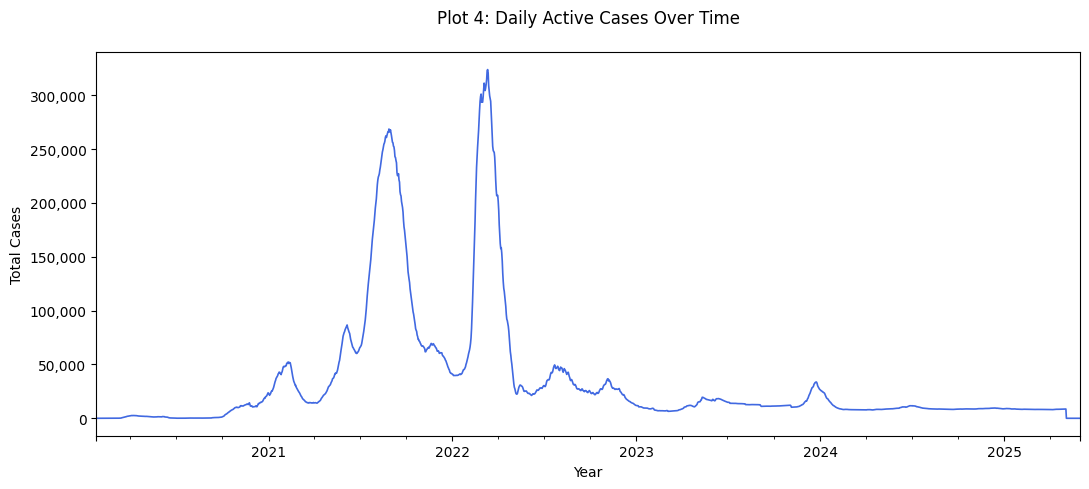

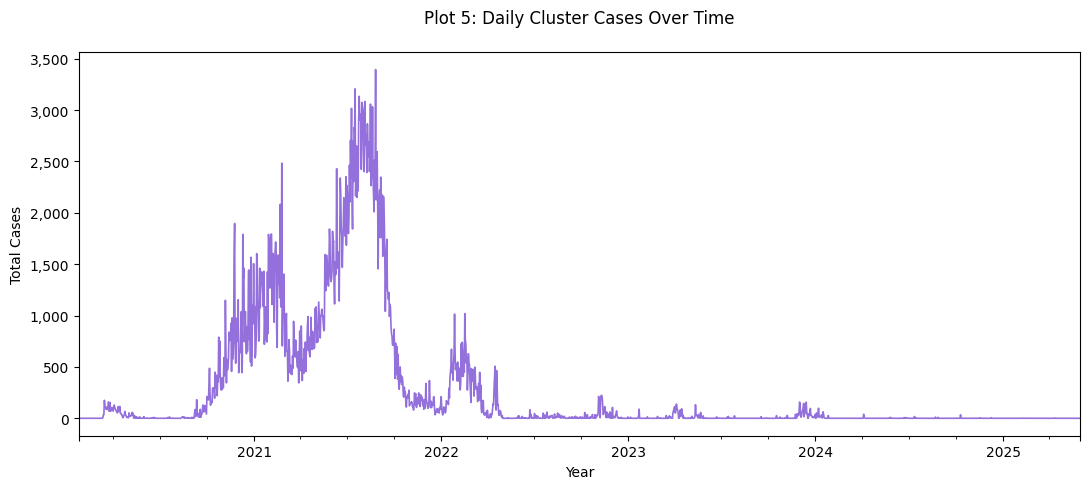

In [28]:
metrics = {
    "1": ("cases_new",       "Daily New Cases",       "tomato"),
    "2": ("cases_import",    "Daily Imported Cases",  "darkorange"),
    "3": ("cases_recovered", "Daily Recovered Cases", "mediumseagreen"),
    "4": ("cases_active",    "Daily Active Cases",    "royalblue"),
    "5": ("cases_cluster",   "Daily Cluster Cases",   "mediumpurple"),
}

for label, (col, title, colour) in metrics.items():
    daily = cases.groupby("date")[col].sum()
    plt.figure(figsize=(11, 5))
    daily.plot(color=colour, linewidth=1.2)
    plt.title(f"Plot {label}: {title} Over Time\n",
              fontsize=12)
    plt.ylabel("Total Cases")
    plt.xlabel("Year")
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    plt.tight_layout()
    fname = f"{label}_{col}_trend.png"
    plt.show()


The chart suggests that COVID-19 cases rose gradually through 2021, then surged sharply in late 2021 and especially early 2022, where the highest peaks appear across new, recovered, active, and cluster cases. Import cases stayed relatively low most of the time, but they also spiked around early 2022, which may indicate a period of increased cross-border transmission risk. After that, the overall trend drops and remains much lower through 2023 to 2025, showing that the outbreak became less intense over time. The recovered cases follow the same broad pattern as new cases, usually rising shortly after each wave, while active cases show the most dramatic peak before steadily declining. Overall, the graph indicates that the most serious phase of the outbreak in this dataset was centered in 2021 to early 2022, followed by a sustained easing of transmission.

##6.3 Comparative Trends of COVID-19 New Cases, Recoveries and Active Cases


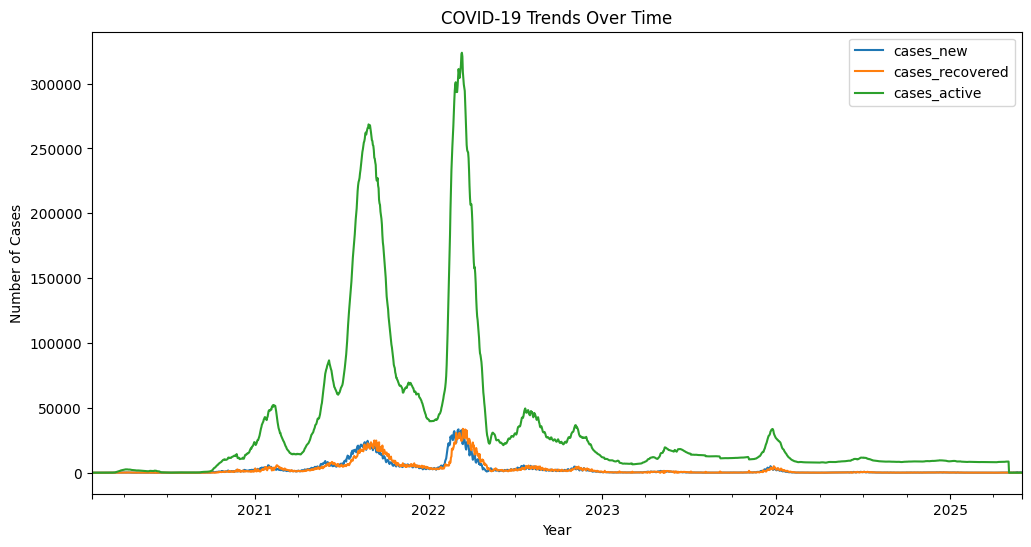

In [29]:
daily = cases.groupby("date")[["cases_new","cases_recovered","cases_active"]].sum()

daily.plot(figsize=(12,6))
plt.title("COVID-19 Trends Over Time")
plt.ylabel("Number of Cases")
plt.xlabel("Year")
plt.show()

This chart illustrates three COVID-19 time-series lines, new cases, recovered cases, and active cases. The active cases line is much higher than the other two, with the biggest surges in late 2021 and early 2022, which indicates the main outbreak waves happened in that period.

The new cases and recovered cases lines rise and fall in a similar pattern, with recovered cases generally lagging behind new cases, which is expected because people recover after being infected. After the early 2022 peak, all three lines decline steadily and stay comparatively low through 2023 to 2025, suggesting the outbreak became less severe over time.

## 6.4 Active vs Recovered Cases by State

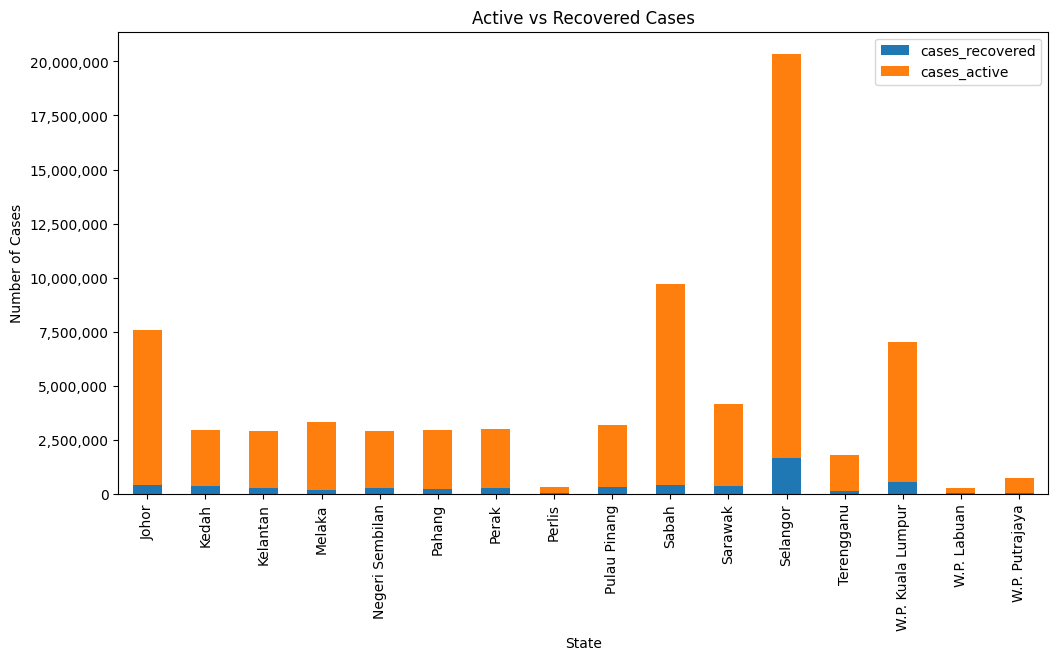

In [30]:
cases.groupby("state")[["cases_recovered","cases_active"]].sum()\
    .plot(kind="bar", stacked=True, figsize=(12,6))

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.ylabel("Number of Cases")
plt.xlabel("State")

plt.title("Active vs Recovered Cases")
plt.show()

This bar chart compares active and recovered COVID-19 cases across Malaysian states. Selangor stands out as the highest by a wide margin, followed by Sabah, Johor, and W.P. Kuala Lumpur, which suggests these areas carried the largest overall case burden in the dataset.

Across most states, active cases dominate the totals, while recovered cases make up a smaller portion of each bar. Smaller populations such as Perlis, W.P. Labuan, and W.P. Putrajaya show much lower totals, which is consistent with their smaller size and lower case volume. The chart suggests that COVID-19 impact was not evenly distributed, but concentrated more heavily in larger and more urban states.

## 6.5 Vaccination Status by State

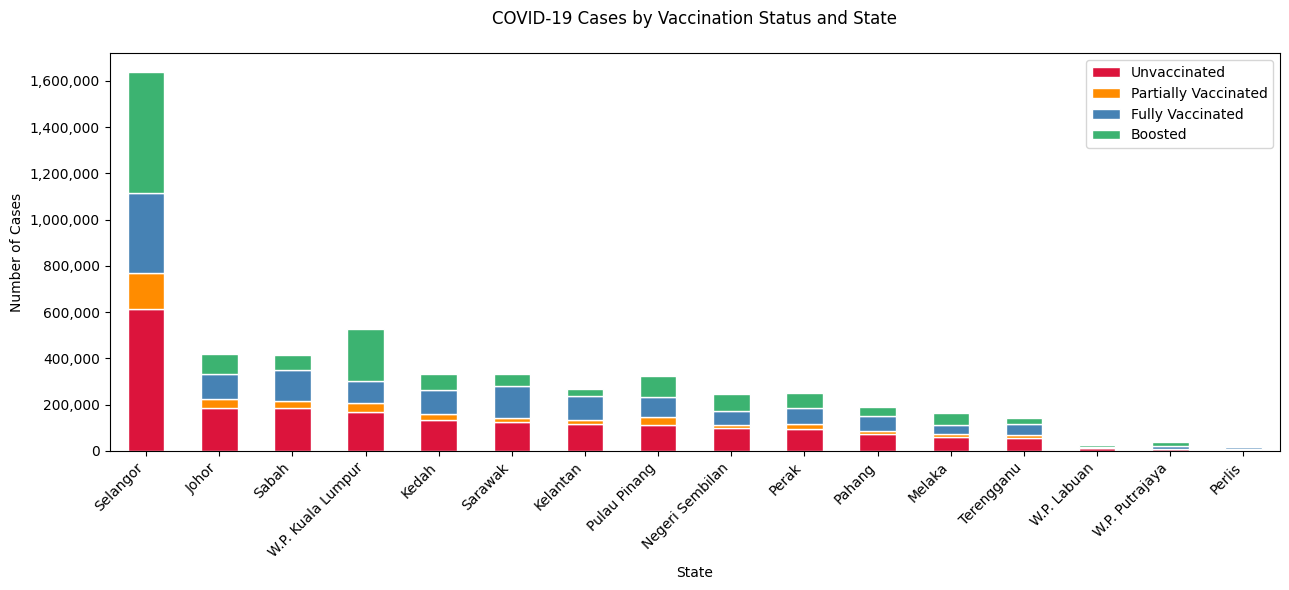

In [31]:
vax_summary = (vax.groupby("state")[["cases_unvax", "cases_pvax",
                                      "cases_fvax", "cases_boost"]].sum()
               .sort_values("cases_unvax", ascending=False))

ax = vax_summary.plot(kind="bar", stacked=True, figsize=(13, 6),
                      color=["crimson", "darkorange", "steelblue", "mediumseagreen"],
                      edgecolor="white")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.title("COVID-19 Cases by Vaccination Status and State\n",
          fontsize=12)
plt.ylabel("Number of Cases")
plt.xlabel("State")
plt.xticks(rotation=45, ha="right")
plt.legend(["Unvaccinated", "Partially Vaccinated", "Fully Vaccinated", "Boosted"])
plt.tight_layout()
plt.show()

The bar chart provides a breakdown of cumulative COVID-19 case counts across various states and federal territories in Malaysia, categorized by individual vaccination status (Unvaccinated, Partially Vaccinated, Fully Vaccinated, and Boosted). The chart clearly demonstrates that Selangor has experienced the highest absolute volume of cases by a substantial margin, with a total case count exceeding 1.6 million. Within Selangor's data, the unvaccinated population (represented in crimson red) accounts for the largest share at over 600,000 cases, followed significantly by the boosted (green) and fully vaccinated (blue) segments, while the partially vaccinated (orange) make up the smallest group.

Looking past Selangor, the overall volume of reported cases drops off steeply but follows a distinct regional distribution across the country. Johor, Sabah, and W.P. Kuala Lumpur form the next tier of highly impacted regions, each tracking between roughly 400,000 and 520,000 total cases. Interestingly, W.P. Kuala Lumpur stands out within this cluster because its green "Boosted" bar segment is visually much larger than its "Unvaccinated" or "Fully Vaccinated" segments, contrasting sharply with states like Johor and Sabah where unvaccinated individuals represent the largest portion of the case count. Moving further right down the chart, a steady decline is visible across states like Kedah, Sarawak, Kelantan, and Pulau Pinang, which hover closer to the 300,000 case mark, down to Pahang, Melaka, and Terengganu, which fall well below 200,000 cases. Finally, the federal territories of W.P. Labuan and W.P. Putrajaya, alongside the state of Perlis, represent the lowest case totals on the chart, appearing as minuscule bars barely registering above the baseline due to their smaller population sizes.

##6.6 Age Group Distribution

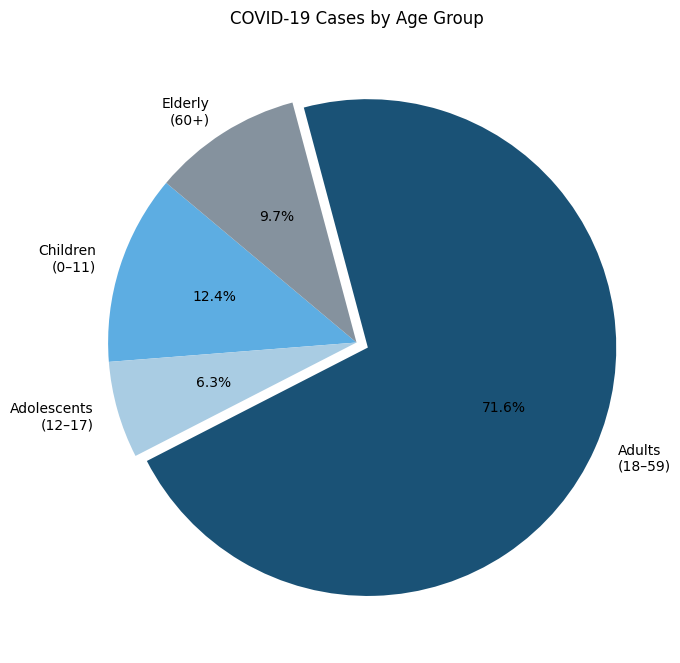

In [32]:
age_totals = age[["cases_child", "cases_adolescent",
                  "cases_adult", "cases_elderly"]].sum()
labels = ["Children\n(0–11)", "Adolescents\n(12–17)",
          "Adults\n(18–59)", "Elderly\n(60+)"]
explode = [0, 0, 0.05, 0]  # slightly separate Adults slice

plt.figure(figsize=(7, 7))
plt.pie(age_totals, labels=labels, autopct="%1.1f%%",
        explode=explode, startangle=140,
        colors=["#5dade2", "#a9cce3", "#1a5276", "#85929e"])
plt.title("COVID-19 Cases by Age Group"
          , fontsize=12)
plt.tight_layout()
plt.show()

The pie chart illustrates the percentage distribution of total COVID-19 cases across four distinct age demographics. The data clearly shows that Adults (18–59) make up the overwhelming majority of cases, accounting for 71.6% of the entire chart, represented by the large slice. The remaining segments constitute less than a third of total cases combined. Among these smaller demographics, Children (0–11) represent the second-largest group at 12.4%, followed by the Elderly (60+) at 9.7%. Adolescents (12–17) make up the smallest proportion of recorded infections, accounting for just 6.3% of the total distribution.

##6.7 Correlation Heatmap

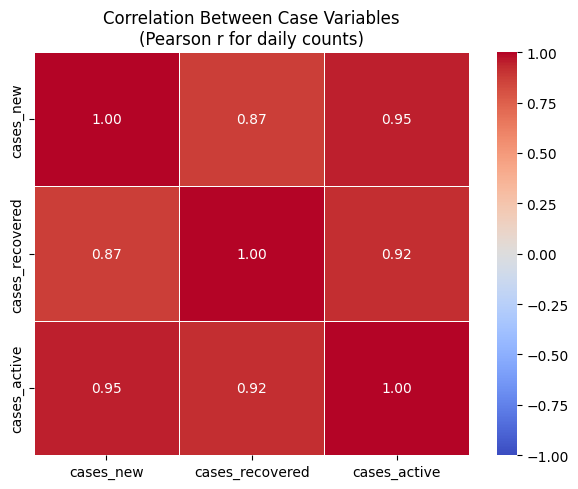

In [33]:
import seaborn as sns

corr_data = cases[["cases_new", "cases_recovered", "cases_active"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Between Case Variables\n"
          "(Pearson r for daily counts)", fontsize=12)
plt.tight_layout()
plt.show()

The heatmap chart illustrates the strength and direction of the linear relationships between three daily COVID-19 metrics: new cases (`cases_new`), recovered cases (`cases_recovered`), and active cases (`cases_active`). All three variables show exceptionally strong, positive correlations with one another, as indicated by the deep red shading and Pearson correlation coefficients ($r$) near 1.00. The strongest relationship between two differing variables is found between new cases and active cases, boasting a very high correlation of 0.95, which reflects how directly a surge in daily infections drives up the active caseload. Active cases and recovered cases are also highly intertwined with a correlation of 0.92, showing a predictable lag-and-flow pattern as active infections eventually transition into recoveries. Finally, the connection between new cases and recovered cases is the lowest among the pairs but remains incredibly robust at 0.87, highlighting the overall synchronized nature of the pandemic's acceleration and resolution cycles.

##6.8 Monthly New Cases Heatmap

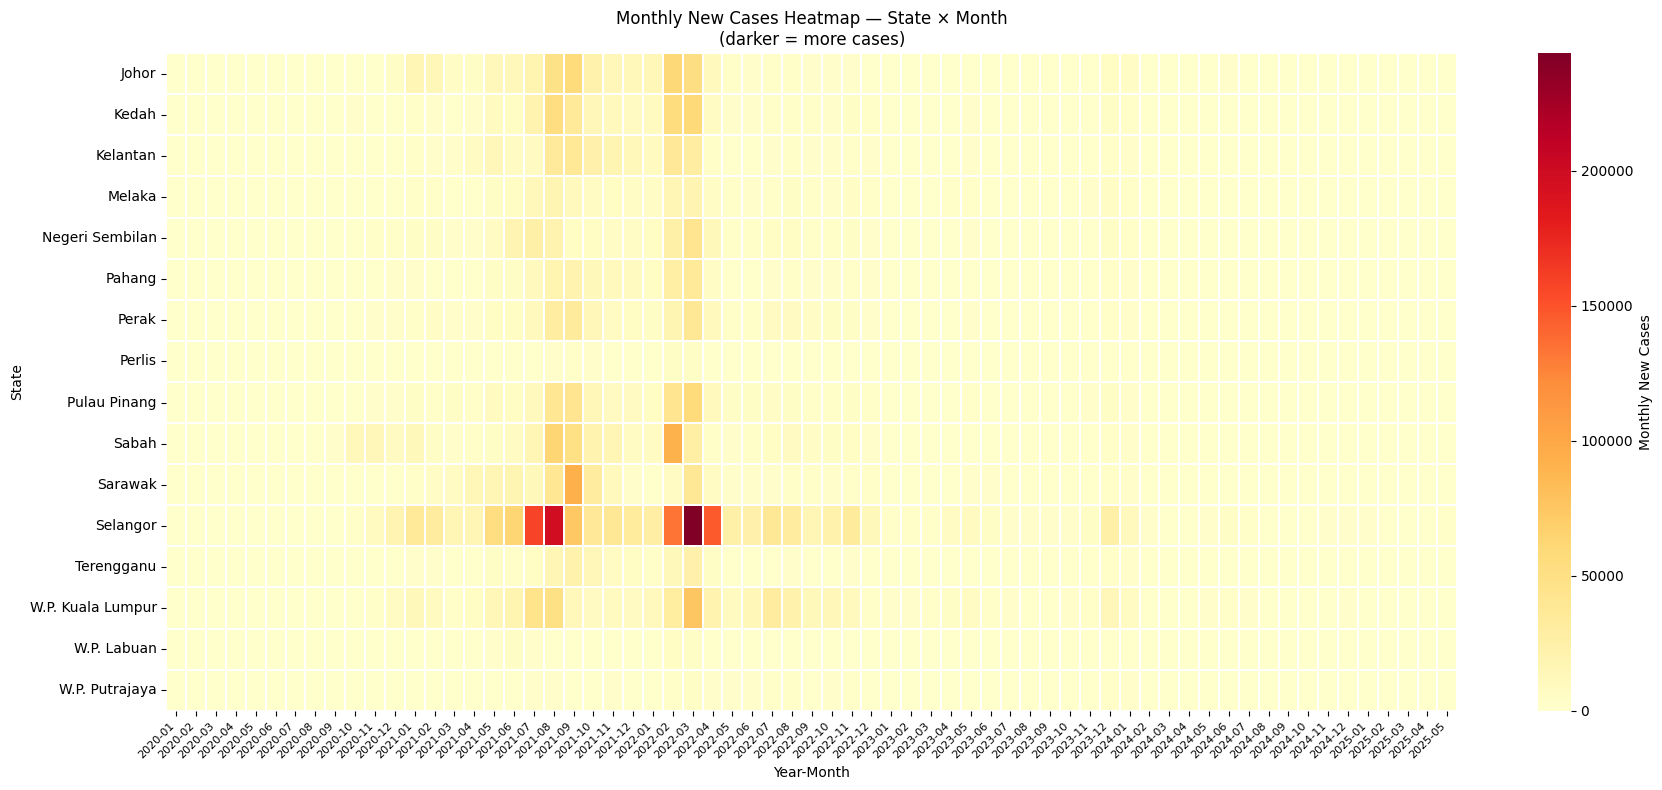

In [34]:
cases["year_month"] = cases["date"].dt.to_period("M")
monthly_pivot = (cases.groupby(["state", "year_month"])["cases_new"]
                 .sum()
                 .unstack(fill_value=0))
# Convert Period index to string for cleaner axis labels
monthly_pivot.columns = monthly_pivot.columns.astype(str)

plt.figure(figsize=(18, 8))
sns.heatmap(monthly_pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Monthly New Cases"})
plt.title("Monthly New Cases Heatmap — State × Month\n"
          "(darker = more cases)", fontsize=12)
plt.ylabel("State")
plt.xlabel("Year-Month")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

The heatmap visualizes the density of monthly new COVID-19 cases across Malaysian states from January 2020 through May 2025. According to the color scale on the right, lighter yellow squares represent low or zero case counts, while darkening shades of orange, red, and deep maroon signify increasingly severe outbreaks, peaking above 200,000 cases in a single month.

The chart clearly highlights that Selangor experienced the most intense and sustained burden of the pandemic compared to all other regions. Selangor's row lights up significantly with bright red and deep maroon blocks during two primary waves. The first severe cluster occurs in mid-to-late 2021, specifically peaking in 2021-07 and 2021-08, where the color transitions into a deep crimson. The second and most severe outbreak occurs in early 2022, peaking explicitly in 2022-03 with a dark maroon block that marks the highest single-month case concentration on the entire chart.

While Selangor dominates the visualization, several other states show visible orange blocks during these exact same periods, indicating synchronized nationwide surges. During the late 2021 wave, Sarawak shows a distinct orange spike slightly later than Selangor, around 2021-09. During the absolute peak in 2022-03, states like Johor, Kedah, Pulau Pinang, Sabah, and W.P. Kuala Lumpur all exhibit prominent light-orange blocks, showcasing the widespread nature of that specific variant wave. Outside of these major windows, specifically throughout 2020 and from mid-2022 onwards into 2025, the chart is almost entirely pale yellow, illustrating that monthly new case counts remained low and stable across all states during the beginning and final phases of the timeline.

##6.9 COVID-19 Cases by Age Group and State

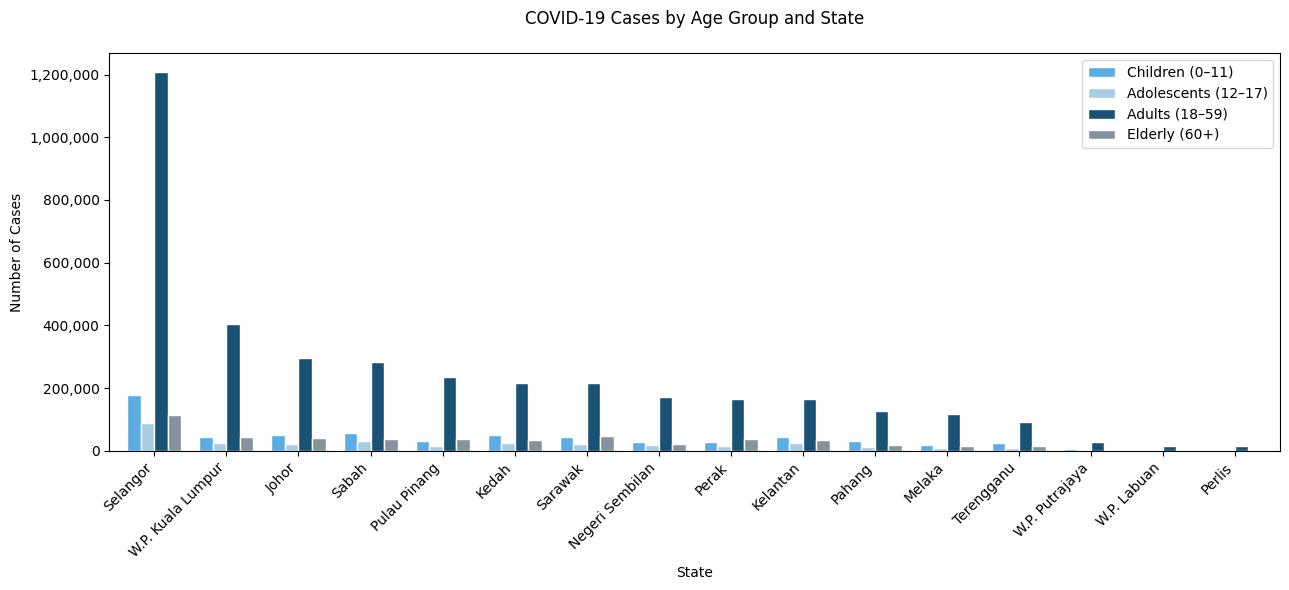

In [35]:
age_by_state = (age.groupby("state")[["cases_child", "cases_adolescent",
                                       "cases_adult", "cases_elderly"]].sum()
                .sort_values("cases_adult", ascending=False))

ax = age_by_state.plot(kind="bar", figsize=(13, 6),
                       color=["#5dade2", "#a9cce3", "#1a5276", "#85929e"],
                       edgecolor="white", width=0.75)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.title("COVID-19 Cases by Age Group and State\n"
         , fontsize=12)
plt.ylabel("Number of Cases")
plt.xlabel("State")
plt.xticks(rotation=45, ha="right")
plt.legend(["Children (0–11)", "Adolescents (12–17)",
            "Adults (18–59)", "Elderly (60+)"])
plt.tight_layout()
plt.show()

The grouped bar chart explains the cumulative COVID-19 case counts across different Malaysian states and federal territories, categorized into four distinct age demographics. Across every single state and territory visualized on the graph, adults aged 18 to 59, represented by the dark blue bars, comprise the overwhelming majority of the total case volume by a substantial margin. Selangor stands out as an extreme outlier on the far left of the chart, tracking the highest case numbers across all demographics and reaching an adult case count that exceeds 1.2 million. Following Selangor, a secondary tier of highly impacted regions includes W.P. Kuala Lumpur, Johor, and Sabah, with adult cases ranging between roughly 300,000 and 400,000. Among the non-adult demographics, a relatively consistent pattern emerges across most states where children aged 0 to 11 typically make up the second-highest case volume, followed closely by the elderly population aged 60 and above, while adolescents aged 12 to 17 consistently account for the smallest share of reported infections. Toward the right side of the axis, the data tapers off significantly, showing that less populated areas like W.P. Putrajaya, W.P. Labuan, and Perlis recorded minimal case counts across all age brackets, with only their adult bars being visibly noticeable on this scale.

# 7.0 Recommendations
Based on the findings, the following recommendations can be proposed:

#### 1. **Prioritize High-Risk States for Resource Allocation**

States with the highest risk scores, particularly Selangor, Sabah, Johor and W.P. Kuala Lumpur, should receive priority in healthcare resource distribution. Additional hospital beds, medical personnel, testing facilities, and emergency response capabilities should be concentrated in these areas to manage potential outbreaks effectively.

#### 2. **Strengthen Vaccination and Booster Programs**

Since the risk score incorporates the unvaccinated population, targeted vaccination campaigns should be conducted in high-risk states. Efforts should focus on increasing booster uptake among vulnerable populations, especially the elderly and individuals with underlying health conditions.

#### 3. **Enhance Surveillance and Early Warning Systems**

Continuous monitoring of new and active cases should be maintained, particularly in high-risk regions. Real-time surveillance systems can help detect emerging outbreaks early and enable authorities to implement rapid containment measures before widespread transmission occurs.

#### 4. **Protect Elderly and Vulnerable Groups**

Given that the elderly population contributes to the risk score, special protective measures should be implemented in states with larger elderly populations. These measures may include regular health screenings, priority vaccination programs, and enhanced infection control practices in nursing homes and healthcare facilities.

#### 5. **Implement Targeted Public Health Interventions**

Rather than applying nationwide restrictions, authorities can adopt localized interventions in states with higher risk scores. Such measures may include intensified testing, contact tracing, public awareness campaigns, and temporary restrictions in identified hotspots.

#### 6. **Maintain Preparedness in Moderate- and Lower-Risk States**

Although states such as Melaka, Pulau Pinang, Perak, Kedah and Pahang exhibit lower risk scores, they should continue monitoring infection trends and maintaining healthcare readiness to prevent future surges.


#8.0 Conclusion

This project, COVID-19 Analysis in Malaysia Using Apache Hive and Spark, successfully demonstrates the application of big data technologies in analyzing large scale COVID-19 datasets. By leveraging Apache Hive for data storage and querying and Apache Spark for distributed data processing and analytics, the study efficiently handled COVID-19 data across multiple states and time periods in Malaysia.

The analysis revealed several important trends. New COVID-19 cases experienced multiple waves, with the most significant surge occurring in 2021 and early 2022. Recovery trends generally followed increases in new cases, indicating the healthcare system's capacity to manage infected patients. Active cases rose sharply during major outbreak periods before gradually declining as recovery rates improved. Imported cases remained relatively low throughout most of the pandemic, except for a notable spike in early 2022, likely associated with border reopening and increased international travel. Furthermore, the composite risk score analysis identified Selangor, Sabah, Johor, and W.P. Kuala Lumpur as the most vulnerable regions, highlighting the unequal distribution of COVID-19 risk across Malaysia.

The use of visualization techniques, moving averages, and risk-score modeling provided deeper insights into pandemic dynamics and enabled easier identification of trends, peaks, and high-risk regions. These findings demonstrate how data-driven approaches can support evidence-based decision-making, resource allocation, and public health planning.

Overall, this project highlights the effectiveness of Apache Hive and Spark as powerful big data tools for processing, analyzing, and visualizing large healthcare datasets. The developed analytical framework can serve as a foundation for future epidemic surveillance and preparedness systems, allowing health authorities to monitor disease patterns, identify vulnerable regions, and implement proactive interventions should another outbreak or pandemic wave occur in the future.

#9.0 References



1. Agapito, G., Zucco, C., & Cannataro, M. (2020). COVID-warehouse: A data warehouse of Italian COVID-19, pollution, and climate data. International Journal of Environmental Research and Public Health, 17(15), 5596.



2. Azeroual, O., & Fabre, R. (2021). Processing big data with Apache Hadoop in the current challenging era of COVID-19. Big Data and Cognitive Computing, 5(1), 12.



3. Cheong, Y. L., Ghazali, S. M., Che Ibrahim, M. K. B., Kee, C. C., Md Iderus, N. H., Ruslan, Q. B., Lim, K. H., et al. (2022). Assessing the spatiotemporal spread pattern of the COVID-19 pandemic in Malaysia. Frontiers in Public Health, 10, 836358.



4. Elengoe, A. (2020). COVID-19 outbreak in Malaysia. Osong Public Health and Research Perspectives, 11(3), 93-100.

5. George, M. M., & Rasmi, P. S. (2022). Performance comparison of Apache Hadoop and Apache Spark for COVID-19 data sets. In 2022 4th International Conference on Smart Systems and Inventive Technology (ICSSIT) (pp. 1659-1665). IEEE.



6. Hashim, J. H., Adman, M. A., Hashim, Z., Mohd Radi, M. F., & Kwan, S. C. (2021). COVID-19 epidemic in Malaysia: Epidemic progression, challenges, and response. Frontiers in Public Health, 9, 560592.



7. Ministry of Health Malaysia & World Health Organization. (2022, July 15). Coronavirus disease (COVID-19) situation reports in Malaysia. World Health Organization.



8. Rahmani, A. M., & Mirmahaleh, S. Y. H. (2021). Coronavirus disease (COVID-19) prevention and treatment methods and effective parameters: A systematic literature review. Sustainable Cities and Society, 64, 102568.



9. Shi, Y., Wang, G., Cai, X. P., Deng, J. W., Zheng, L., Zhu, H. H., Zheng, M., Yang, B., & Chen, Z. (2020). An overview of COVID-19. Journal of Zhejiang University-SCIENCE B, 21(5), 343-360.



10. Data.gov.my. Government of Malaysia.